In [1]:
%load_ext autoreload
%autoreload 2


%run ../src/run.py --help


usage: run.py [-h] [--seed SEED] --experiment
              {mnist2,pmnist,cifar,mixture,easy-chasy,hard-chasy,smnist}
              --approach
              {random,sgd,sgd-frozen,lwf,lfl,ewc,imm-mean,progressive,pathnet,imm-mode,sgd-restart,ewc2,ewc-film,joint,hat,hat-test,gvcl,vcl,vclf,gvclf}
              [--output OUTPUT] [--nepochs NEPOCHS] [--lr LR]
              [--parameter PARAMETER] [--ntasks NTASKS]
              [--use-best-hyperparams USE_BEST_HYPERPARAMS]

xxx

options:
  -h, --help            show this help message and exit
  --seed SEED           (default=0)
  --experiment {mnist2,pmnist,cifar,mixture,easy-chasy,hard-chasy,smnist}
                        (default=)
  --approach {random,sgd,sgd-frozen,lwf,lfl,ewc,imm-mean,progressive,pathnet,imm-mode,sgd-restart,ewc2,ewc-film,joint,hat,hat-test,gvcl,vcl,vclf,gvclf}
                        (default=)
  --output OUTPUT       (default=)
  --nepochs NEPOCHS     (default=-1)
  --lr LR               (default=-1.000000)
  --pa

In [2]:
import torch
print(torch.cuda.is_available())

True


In [5]:
%run ../src/run.py --experiment cifar --approach gvcl --seed 5

Arguments =
	seed: 5
	experiment: cifar
	approach: gvcl
	output: ../res/cifar_gvcl_5.txt
	nepochs: -1
	lr: -1
	parameter: 
	ntasks: -1
	use_best_hyperparams: True
approach VCL True
Load data...
Task order = [0, 1, 2, 3, 4, 5]
Input size = [3, 32, 32] 
Task info = [(0, 10), (1, 10), (2, 10), (3, 10), (4, 10), (5, 10)]
Inits...
Film type point
----------------------------------------------------------------------------------------------------
Net(
  (conv_layers): ModuleList(
    (0): MFConvLayer(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MFConvLayer(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): MFConvLayer(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): MFConvLayer(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (fc_layers): ModuleList(
    (0): MFLinearLayer()
  )
  (heads): ModuleList(
    (0-5): 6 x MFLinearLayer()
  )
  (conv_film_layers): ModuleList(
    (0-3): 4 x PointFiLMLayer()
  )
  (fc_film_lay

KeyboardInterrupt: 

In [11]:
import torch
import torch.distributions as dist

def compute_kl(mean, exp_var, prior_mean, prior_exp_var, sum = True, lamb = 1, initial_prior_var = 1):
    #print("mean shape:", mean.shape)
    #print("exp_var shape:", exp_var.shape)
    #print("prior_mean shape:", prior_mean.shape)
    #print("prior_exp_var shape:", prior_exp_var.shape)
    trace_term = torch.exp(exp_var - prior_exp_var)
    if lamb != 1:
        mean_term =  (mean - prior_mean)**2 * (lamb * torch.clamp(torch.exp(-prior_exp_var) - (1/initial_prior_var), min = 0.0) + (1/initial_prior_var))
    else:
        mean_term =  (mean - prior_mean)**2 * torch.exp(-prior_exp_var)
    det_term = prior_exp_var - exp_var
    
    if sum:
        return 0.5 * torch.sum(trace_term + mean_term + det_term - 1)
    else:
        return 0.5 * (trace_term + mean_term + det_term - 1)

def compute_renyi(mean, log_var, prior_mean, log_prior_var,  sum = True, lamb = 1, initial_prior_var = 1, alpha = 0.5):
    """
    Compute the Rényi divergence between univariate Gaussian posterior and prior distributions.
    
    Args:
        mean (torch.Tensor): Posterior mean (shape: [n]).
        log_var (torch.Tensor): Log-variance of the posterior (shape: [n]).
        prior_mean (torch.Tensor): Prior mean (shape: [n]).
        log_prior_var (torch.Tensor): Log-variance of the prior (shape: [n]).
        alpha (float): Order of the Rényi divergence (alpha > 0, alpha != 1).
    
    Returns:
        torch.Tensor: Rényi divergence for each element in the input tensor (shape: [n]).
    """
    # Compute posterior variance and prior variance from log-variances
    var = torch.exp(log_var)  # Posterior variance
    prior_var = torch.exp(log_prior_var)  # Prior variance

    # Compute the mixed variance (Σ_α)^*
    mixed_var = alpha * prior_var + (1 - alpha) * var

    # Compute the Mahalanobis term: α (μ - μ_prior)^2 / (Σ_α)^*
    mahalanobis_term = alpha * (mean - prior_mean) ** 2 / mixed_var

    # Compute the determinant term: log(|Σ_α^*|) - ((1 - α) log(|Σ|) + α log(|Σ_prior|))
    log_det_term = torch.log(mixed_var) - ((1 - alpha) * log_var + alpha * log_prior_var)

    if sum:
        return 0.5 * torch.sum(mahalanobis_term - 0.5 / (alpha - 1) * log_det_term)
    # Combine terms to compute Rényi divergence
    else:
        return 0.5 * mahalanobis_term - 0.5 / (alpha - 1)

def compute_kl_true(mean, exp_var, prior_mean, prior_exp_var, sum = True, lamb = 1, initial_prior_var = 1):

    '''
    Computes the Dkl(approximate distribution || prior distribution) between two Gaussian distributions

    Note that the variances are log variances
    '''

    dist1 = dist.MultivariateNormal(mean, exp_var)
    dist2 = dist.MultivariateNormal(prior_mean, prior_exp_var)
    kl_loss = torch.distributions.kl.kl_divergence(dist1, dist2)
    return kl_loss

Sanity check that what is being done is computing the KL for a diagonal covariance matrix. With compute_kl true we can introduce interdependencies, try with it as well

In [15]:
# Example usage
# Example usage for 10x10 diagonal covariance matrix
mu1 = torch.tensor([0.0] * 10)
cov1 = torch.diag(torch.tensor([1.0] * 10))
mu2 = torch.tensor([1.0] * 10)
cov2 = torch.diag(torch.tensor([2.0] * 10))

mu1_univariate = torch.tensor([0.0])
cov1_univariate = torch.tensor([[1.0]])
mu2_univariate = torch.tensor([1.0])
cov2_univariate = torch.tensor([[2.0]])

kl_loss = compute_kl_true(mu1, cov1, mu2, cov2)
kl_term = compute_kl(mu1, torch.log(torch.diag(cov1)), mu2, torch.log(torch.diag(cov2)))
renyi_term = compute_renyi(mu1, torch.log(torch.diag(cov1)), mu2, torch.log(torch.diag(cov2)))

kl_loss_univariate = compute_kl_true(mu1_univariate, cov1_univariate, mu2_univariate, cov2_univariate)
kl_term_univariate2 = compute_kl(mu1_univariate, torch.log(cov1_univariate), mu2_univariate, torch.log(cov2_univariate))
renyi_term_univariate = compute_renyi(mu1_univariate, torch.log(cov1_univariate), mu2_univariate, torch.log(cov2_univariate))

print("KL Loss multivariate (torch implementation):", kl_loss)
print("KL loss:", kl_term)
print("Renyi term multivariate:", renyi_term)

print("KL Loss univariate (torch implementation):", kl_loss_univariate)
print("KL loss:", kl_term_univariate2)
print("Renyi term univariate:", renyi_term_univariate)



KL Loss multivariate (torch implementation): tensor(3.4657)
KL loss: tensor(3.4657)
Renyi term multivariate: tensor(1.9611)
KL Loss univariate (torch implementation): tensor(0.3466)
KL loss: tensor(0.3466)
Renyi term univariate: tensor(0.1961)


In [13]:
torch.diag(cov1)

tensor([1., 2.])

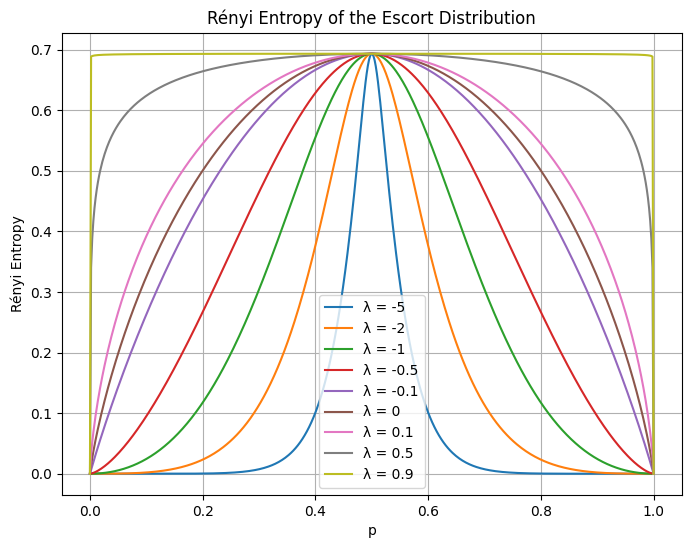

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def escort_distribution(p, alpha):
    """
    Compute the escort distribution for a given p and alpha.

    Parameters:
    - p: array-like, probabilities of the original distribution
    - alpha: float, deformation parameter (same as q)

    Returns:
    - Escort distribution: normalized deformed probabilities
    """
    deformed_p = p ** alpha
    return deformed_p / np.sum(deformed_p)

def renyi_entropy(p, alpha):
    """
    Compute the Rényi entropy for the escort distribution.

    Parameters:
    - p: array-like, probabilities of the original distribution
    - alpha: float, deformation parameter (same as q)

    Returns:
    - Rényi entropy value
    """
    if alpha == 1:
        # Shannon entropy as a special case
        return -np.sum(p * np.log(p + 1e-12))
    else:
        return (1 / (1 - alpha)) * np.log(np.sum(p ** alpha))

def plot_renyi_entropy():
    """
    Plot the Rényi entropy of the escort distribution as a function of p
    for different values of alpha (or lambda).
    """
    p_values = np.linspace(0, 1, 500)  # p values in [0, 1]
    lambdas = [-5, -2, -1, -0.5, -0.1, 0, 0.1, 0.5, 0.9]  # Lambda values
    alpha_values = [1 - lam for lam in lambdas]  # Alpha = 1 - lambda
    entropy_values = []

    for alpha in alpha_values:
        entropies = []
        for p in p_values:
            original_p = np.array([p, 1 - p])  # Binary distribution
            escort_p = escort_distribution(original_p, alpha)
            entropy = renyi_entropy(escort_p, alpha)
            entropies.append(entropy)
        entropy_values.append(entropies)

    # Plot the results
    plt.figure(figsize=(8, 6))
    for i, lam in enumerate(lambdas):
        plt.plot(p_values, entropy_values[i], label=f"λ = {lam}")
    plt.xlabel("p")
    plt.ylabel("Rényi Entropy")
    plt.title("Rényi Entropy of the Escort Distribution")
    plt.legend()
    plt.grid(True)
    plt.show()

# Run the updated plot function
plot_renyi_entropy()


In [12]:
import torch

# Define a class with the get_kl method
class ExampleModel:
    def __init__(self, regtype):
        self.regtype = regtype
        self.weight = torch.tensor([0.0, 1.0, 2.0])
        self.weight_var = torch.tensor([0.1, 0.2, 0.3])
        self.W_prior_mean = torch.tensor([1.0, 2.0, 3.0])
        self.W_prior_var = torch.tensor([0.2, 0.3, 0.4])
        self.bias = torch.tensor([0.5, 1.5, 2.5])
        self.bias_var = torch.tensor([0.2, 0.3, 0.4])
        self.b_prior_mean = torch.tensor([1.0, 2.0, 3.0])
        self.b_prior_var = torch.tensor([0.2, 0.3, 0.4])
        self.prior_var = 1

    def get_kl(self, lamb):
        if self.regtype == 'kl':
            kl_function = compute_kl
        elif self.regtype == 're':
            kl_function = compute_re
        else:
            raise ValueError(f"Unknown regularization type: {self.regtype}")

        W_kl = kl_function(self.weight, self.weight_var, self.W_prior_mean, self.W_prior_var, lamb=lamb, initial_prior_var=self.prior_var)
        b_kl = kl_function(self.bias, self.bias_var, self.b_prior_mean, self.b_prior_var, lamb=lamb, initial_prior_var=self.prior_var)
        return W_kl + b_kl

def compute_re(mean, exp_var, prior_mean, prior_exp_var, sum = True, lamb = 1, initial_prior_var = 1):
    #print("mean shape:", mean.shape)
    #print("exp_var shape:", exp_var.shape)
    #print("prior_mean shape:", prior_mean.shape)
    #print("prior_exp_var shape:", prior_exp_var.shape)
    trace_term = torch.exp(exp_var - prior_exp_var)
    if lamb != 1:
        mean_term =  (mean - prior_mean)**2 * (lamb * torch.clamp(torch.exp(-prior_exp_var) - (1/initial_prior_var), min = 0.0) + (1/initial_prior_var))
    else:
        mean_term =  (mean - prior_mean)**2 * torch.exp(-prior_exp_var)
    det_term = prior_exp_var - exp_var
    
    if sum:
        return 0.5 * torch.sum(trace_term + mean_term + det_term - 1)
    else:
        return 0.5 * (trace_term + mean_term + det_term - 1)


#extend compute kl method to choose renyi between gaussians, renyi between q-gaussians, kl between q gaussians or kl begtween gaussians

def compute_kl(mean, log_var, prior_mean, log_prior_var,  sum = True, lamb = 1, initial_prior_var = 1, alpha = 2):
    """
    Compute the Rényi divergence between univariate Gaussian posterior and prior distributions.
    
    Args:
        mean (torch.Tensor): Posterior mean (shape: [n]).
        log_var (torch.Tensor): Log-variance of the posterior (shape: [n]).
        prior_mean (torch.Tensor): Prior mean (shape: [n]).
        log_prior_var (torch.Tensor): Log-variance of the prior (shape: [n]).
        alpha (float): Order of the Rényi divergence (alpha > 0, alpha != 1).
    
    Returns:
        torch.Tensor: Rényi divergence for each element in the input tensor (shape: [n]).
    """
    # Compute posterior variance and prior variance from log-variances
    var = torch.exp(log_var)  # Posterior variance
    prior_var = torch.exp(log_prior_var)  # Prior variance

    # Compute the mixed variance (Σ_α)^*
    mixed_var = alpha * prior_var + (1 - alpha) * var

    # Compute the Mahalanobis term: α (μ - μ_prior)^2 / (Σ_α)^*
    mahalanobis_term = alpha * (mean - prior_mean) ** 2 / mixed_var

    # Compute the determinant term: log(|Σ_α^*|) - ((1 - α) log(|Σ|) + α log(|Σ_prior|))
    log_det_term = torch.log(mixed_var) - ((1 - alpha) * log_var + alpha * log_prior_var)

    if sum:
        return 0.5 * torch.sum(mahalanobis_term - 0.5 / (alpha - 1) * log_det_term)
    # Combine terms to compute Rényi divergence
    else:
        return 0.5 * mahalanobis_term - 0.5 / (alpha - 1)

# Create an instance of ExampleModel with regtype 'kl'
model_kl = ExampleModel(regtype='kl')
kl_loss = model_kl.get_kl(lamb=1)
print("KL Loss:", kl_loss)

# Create an instance of ExampleModel with regtype 're'
model_re = ExampleModel(regtype='re')
re_loss = model_re.get_kl(lamb=1)
print("Rényi Loss:", re_loss)

KL Loss: tensor(2.6004)
Rényi Loss: tensor(1.4009)
